# Result Comparision on DCGAN vs VAE

In [1]:
import mlx.core as mx
import mlx.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
def upsample_nearest(x, scale=2):
    B, H, W, C = x.shape
    x = mx.broadcast_to(x[:, :, None, :, None, :], (B, H, scale, W, scale, C))
    x = x.reshape(B, H * scale, W * scale, C)
    return x


class UpsamplingConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size, stride=1, padding=padding
        )

    def __call__(self, x):
        return self.conv(upsample_nearest(x))

In [3]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=200):
        super().__init__()
        # Increased capacity: 64 -> 128 -> 256
        self.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(64, 128, 3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm(128)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(128, 256, 3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm(256)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.flatten_size = 4 * 4 * 256
        self.output_layer = nn.Linear(self.flatten_size, latent_dim)
        self.bn_out = nn.BatchNorm(latent_dim)

    def __call__(self, x):
        x = nn.silu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = nn.silu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = nn.silu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = x.reshape(x.shape[0], -1)
        x = nn.silu(self.bn_out(self.output_layer(x)))
        return x


class Decoder(nn.Module):
    def __init__(self, latent_dim=200):
        super().__init__()
        self.dense = nn.Linear(latent_dim, 4 * 4 * 256)
        self.bn_dense = nn.BatchNorm(4 * 4 * 256)

        self.upconv1 = UpsamplingConv2d(256, 128, 3, padding=1)
        self.bn1 = nn.BatchNorm(128)

        self.upconv2 = UpsamplingConv2d(128, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm(64)

        self.upconv3 = UpsamplingConv2d(64, 64, 3, padding=1)  # Extra layer to smooth
        self.bn3 = nn.BatchNorm(64)

        self.final_conv = nn.Conv2d(64, 3, 3, stride=1, padding=1)

    def __call__(self, x):
        x = nn.silu(self.bn_dense(self.dense(x)))
        x = x.reshape(-1, 4, 4, 256)
        x = nn.silu(self.bn1(self.upconv1(x)))  
        x = nn.silu(self.bn2(self.upconv2(x)))
        x = nn.silu(self.bn3(self.upconv3(x)))
        x = mx.sigmoid(self.final_conv(x))
        return x


class VAE(nn.Module):
    def __init__(self, latent_dim=200):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.proj_mu = nn.Linear(latent_dim, latent_dim)
        self.proj_logvar = nn.Linear(latent_dim, latent_dim)

    def __call__(self, x):
        features = self.encoder(x)
        mu = self.proj_mu(features)
        logvar = self.proj_logvar(features)
        sigma = mx.exp(0.5 * logvar)
        eps = mx.random.normal(sigma.shape)
        z = mu + sigma * eps
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

vae = VAE(latent_dim=200)
vae.load_weights('../models_weights/models_20251120-213618/vae_10.safetensors')
vae

VAE(
  (encoder): Encoder(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), dilation=1, groups=1, bias=True)
    (bn1): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), dilation=1, groups=1, bias=True)
    (bn2): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
    (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), dilation=1, groups=1, bias=True)
    (bn3): BatchNorm(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
    (output_layer): Linear(input_dims=4096, output_dims=200, bias=True)
    (bn_out): BatchNorm(200, eps=1e-05, momentum=0.1, affine=True, track

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        # Project and Reshape: 100 -> 4x4x256
        self.linear = nn.Linear(latent_dim, 4 * 4 * 256)
        self.bn0 = nn.BatchNorm(4 * 4 * 256)

        # 4x4 -> 8x8
        self.up1 = UpsamplingConv2d(256, 128)
        self.bn1 = nn.BatchNorm(128)

        # 8x8 -> 16x16
        self.up2 = UpsamplingConv2d(128, 64)
        self.bn2 = nn.BatchNorm(64)

        # 16x16 -> 32x32
        self.up3 = UpsamplingConv2d(64, 3)
        # No Batch Norm on final layer for Generator

    def __call__(self, x):
        # Dense Block
        x = nn.relu(self.bn0(self.linear(x)))
        x = x.reshape(-1, 4, 4, 256)

        # Conv Blocks
        x = nn.relu(self.bn1(self.up1(x)))
        x = nn.relu(self.bn2(self.up2(x)))

        # Output: Tanh for [-1, 1] range
        x = mx.tanh(self.up3(x))
        return x

dcgan = Generator()
dcgan.load_weights("../cifar_10/dcgan/output_gan tuned2/generator_epoch_20.safetensors")
dcgan

Generator(
  (linear): Linear(input_dims=100, output_dims=4096, bias=True)
  (bn0): BatchNorm(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (up1): UpsamplingConv2d(
    (conv): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), dilation=1, groups=1, bias=True)
  )
  (bn1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (up2): UpsamplingConv2d(
    (conv): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), dilation=1, groups=1, bias=True)
  )
  (bn2): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (up3): UpsamplingConv2d(
    (conv): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), dilation=1, groups=1, bias=True)
  )
)

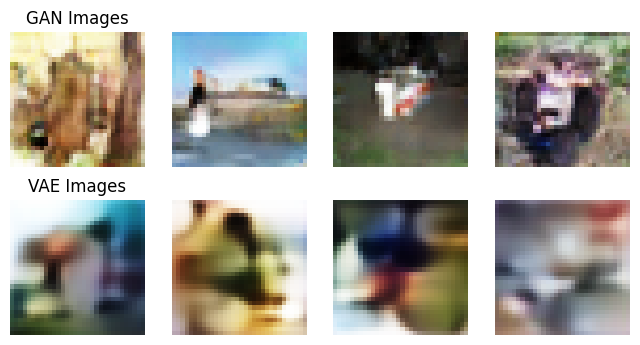

In [5]:
z = lambda count, latent_dim: mx.random.normal((count, latent_dim))
count = 4

gan_images = (dcgan(z(count, 100)) + 1) / 2
mx.eval(gan_images)
gan_images = np.array(gan_images)

vae_images = vae.decoder(z(count, 200))
mx.eval(vae_images)
vae_images = np.array(vae_images)

plt.figure(figsize=(8, 4))
for i in range(1, 5):
    plt.subplot(2, 4, i)
    if i == 1:
        plt.title("GAN Images")
    plt.imshow(gan_images[i-1])
    plt.axis('off')
for i in range(5, 9):
    plt.subplot(2, 4, i)
    if i-5 == 0:
        plt.title("VAE Images")
    plt.imshow(vae_images[i-5])
    plt.axis('off')
plt.savefig('gan_vae_cifar10.png')
plt.show()

In [6]:
class Generator(nn.Module):
    """
    Takes a latent vector (z) and class label (c) and upsamples it to a 28x28x1 image.

    :param latent_dim: Dimension of the input noise vector.
    :param num_classes: Number of classes for conditional generation.
    :param embedding_dim: Dimension of the label embedding.
    """

    def __init__(self, latent_dim, num_classes, embedding_dim):
        super().__init__()

        # Embedding layer for class labels
        self.label_embedder = nn.Embedding(num_classes, embedding_dim)

        # Project latent vector to an initial 7x7x256 feature map
        self.fc = nn.Linear(latent_dim + embedding_dim, 7 * 7 * 256)

        # Upsampling block 1: 7x7 -> 7x7 (stride 1)
        self.conv1 = nn.ConvTranspose2d(256, 128, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm(128)

        # Upsampling block 2: 7x7 -> 14x14 (stride 2)
        self.conv2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=5,
            stride=2,
            padding=2,
            output_padding=1,
        )
        self.bn2 = nn.BatchNorm(64)

        # Upsampling block 3: 14x14 -> 28x28 (stride 2)
        self.conv3 = nn.ConvTranspose2d(
            64,
            1,
            kernel_size=5,
            stride=2,
            padding=2,
            output_padding=1,
        )

    def __call__(self, z, c):
        inputs = mx.concat([self.label_embedder(c), z], axis=1)

        x = self.fc(inputs)
        x = mx.reshape(x, (x.shape[0], 7, 7, 256))  # Reshape to (N, H, W, C)
        x = nn.relu(self.bn1(self.conv1(x)))
        x = nn.relu(self.bn2(self.conv2(x)))

        # Final layer uses tanh to output values between [-1, 1]
        x = mx.tanh(self.conv3(x))
        return x

cgan_fashion_generator = Generator(latent_dim=100, num_classes=10, embedding_dim=16)
cgan_fashion_generator.load_weights('../models_weights/models_20251105-221416/c_dcgan_generator_weights.npz')
cgan_fashion_generator

Generator(
  (label_embedder): Embedding(10, 16)
  (fc): Linear(input_dims=116, output_dims=12544, bias=True)
  (conv1): ConvTranspose2d(256, 128, kernel_size=(5,), stride=(1, 1), padding=(2, 2), dilation=1, output_padding=(0, 0), bias=True)
  (bn1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): ConvTranspose2d(128, 64, kernel_size=(5,), stride=(2, 2), padding=(2, 2), dilation=1, output_padding=(1, 1), bias=True)
  (bn2): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): ConvTranspose2d(64, 1, kernel_size=(5,), stride=(2, 2), padding=(2, 2), dilation=1, output_padding=(1, 1), bias=True)
)

In [7]:
class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Linear(input_dims=latent_dim, output_dims=7 * 7 * 64)
        self.conv1 = nn.ConvTranspose2d(
            in_channels=64,
            out_channels=64,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1,
        )
        self.conv2 = nn.ConvTranspose2d(
            in_channels=64,
            out_channels=32,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1,
        )
        self.output = nn.ConvTranspose2d(
            in_channels=32,
            out_channels=1,
            kernel_size=3,
            padding=1,
        )

    def __call__(self, x) -> mx.array:
        batch_size = x.shape[0]
        x = nn.relu(self.fc(x))
        x = mx.reshape(x, [batch_size, 7, 7, 64])
        x = nn.relu(self.conv1(x))
        x = nn.relu(self.conv2(x))
        x = nn.sigmoid(self.output(x))
        return x

vae_fashion_decoder = Decoder(latent_dim=12)
vae_fashion_decoder.load_weights("../models_weights/models_20251114-205441/decoder_weights_150.safetensors")
vae_fashion_decoder

Decoder(
  (fc): Linear(input_dims=12, output_dims=3136, bias=True)
  (conv1): ConvTranspose2d(64, 64, kernel_size=(3,), stride=(2, 2), padding=(1, 1), dilation=1, output_padding=(1, 1), bias=True)
  (conv2): ConvTranspose2d(64, 32, kernel_size=(3,), stride=(2, 2), padding=(1, 1), dilation=1, output_padding=(1, 1), bias=True)
  (output): ConvTranspose2d(32, 1, kernel_size=(3,), stride=(1, 1), padding=(1, 1), dilation=1, output_padding=(0, 0), bias=True)
)

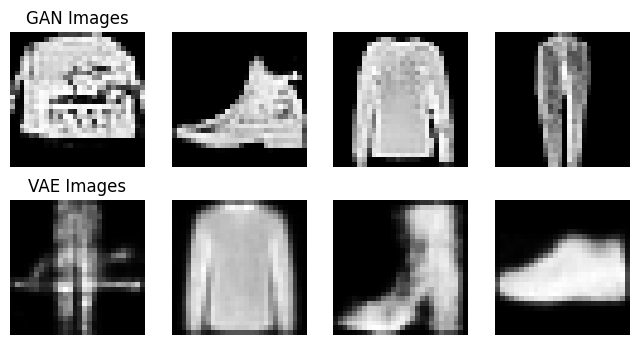

In [10]:
count = 4

gan_images = (
    cgan_fashion_generator(
        z(count, 100),
        mx.random.randint(0, 5, (4,))
    ) + 1
) / 2
mx.eval(gan_images)
gan_images = np.array(gan_images)

vae_images = vae_fashion_decoder(z(count, 12))
mx.eval(vae_images)
vae_images = np.array(vae_images)

plt.figure(figsize=(8, 4))
for i in range(1, 5):
    plt.subplot(2, 4, i)
    if i == 1:
        plt.title("GAN Images")
    plt.imshow(gan_images[i-1], cmap='gray')
    plt.axis('off')
for i in range(5, 9):
    plt.subplot(2, 4, i)
    if i-5 == 0:
        plt.title("VAE Images")
    plt.imshow(vae_images[i-5], cmap='gray')
    plt.axis('off')
plt.savefig('gan_vae_fashion.png')
plt.show()